In [3]:
import pandas as pd
import numpy as np

# Load the dataset
original_df = pd.read_csv('C:\\Datascience_Projects\\Fraud_Detection_Project\\data\\nova_pay_combined.csv')

# Create a copy of the dataset
df = original_df.copy()

# Display basic dataset information
print("Original dataset shape:", original_df.shape)
print("Working copy shape:", df.shape)

# Display the first few rows of the dataset
df.head()

Original dataset shape: (11400, 26)
Working copy shape: (11400, 26)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [6]:
# 1. Drop irrelevant columns (Identfiers)

# Identifiers columns do not usually contribute to the predictive power of the model and can be safely removed.
identifier_columns = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address"
]

# Drop the identifier columns
df.drop(columns=identifier_columns, inplace=True)

print("Dataset shape after dropping identifier columns:", df.shape)
df.head()





Dataset shape after dropping identifier columns: (11400, 22)


,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,True,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [7]:
# 2.  Check and deal with duplicates

# check numbers of duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index after removing duplicates
df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing duplicates:", df.shape)



Number of duplicate rows: 200
Dataset shape after removing duplicates: (11200, 22)


In [8]:
# 4. Fix Inconsistencies in Categorical Variables

# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

# Standardize text formatting in categorical columns
for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

# Display unique values in categorical columns to check for inconsistencies
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in timestamp:
['2022-10-03_18:40:59.468549+00:00' '2022-10-03_20:39:38.468549+00:00'
 '2022-10-03_23:02:43.468549+00:00' ... '2025-11-27_06:19:11.573611+00:00'
 '2025-11-28_00:53:28.573611+00:00' '2025-11-29_20:10:47.573611+00:00']

Unique values in home_country:
['us' 'ca' 'uk' 'unknown']

Unique values in source_currency:
['usd' 'cad' 'gbp']

Unique values in dest_currency:
['cad' 'mxn' 'cny' 'eur' 'inr' 'gbp' 'php' 'ngn' 'usd']

Unique values in channel:
['atm' 'web' 'mobile' 'mobille' 'unknown' 'weeb']

Unique values in amount_src:
['278.19' '208.51' '160.33' ... '537.17' '205.15' '1214.16']

Unique values in ip_country:
['us' 'ca' 'nan' 'uk' 'unknown']

Unique values in kyc_tier:
['standard' 'enhanced' 'low' 'nan' 'standrd' 'unknown' 'enhancd']


In [9]:
# Correct spelling inconsistencies in kyc_tier

df["kyc_tier"] = df["kyc_tier"].replace({
    "standrd": "standard",
    "enhancd": "enhanced",
    "nan": "unknown"
})

# Verify cleaned values
print("Unique values in kyc_tier after correction:")
print(df["kyc_tier"].unique())


df["channel"] = df["channel"].replace({
    "mobille": "mobile",
    "weeb": "web",
})

# Verify cleaned values
print("Unique values in channel after correction:")
print(df["channel"].unique())

Unique values in kyc_tier after correction:
['standard' 'enhanced' 'low' 'unknown']
Unique values in channel after correction:
['atm' 'web' 'mobile' 'unknown']


In [10]:
# ==============================
# Final Check
# ==============================

# Display cleaned dataset information
print("Cleaned dataset shape:", df.shape)
print("\nDataset information:")
df.info()

# Preview cleaned dataset
df.head(20)

Cleaned dataset shape: (11200, 22)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  11200 non-null  object 
 1   home_country               11200 non-null  object 
 2   source_currency            11200 non-null  object 
 3   dest_currency              11200 non-null  object 
 4   channel                    11200 non-null  object 
 5   amount_src                 11200 non-null  object 
 6   amount_usd                 10900 non-null  float64
 7   fee                        10910 non-null  float64
 8   exchange_rate_src_to_dest  11200 non-null  float64
 9   new_device                 11200 non-null  bool   
 10  ip_country                 11200 non-null  object 
 11  location_mismatch          11200 non-null  bool   
 12  ip_risk_score              11200 non-null  fl

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03_18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,...,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,2022-10-03_20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,...,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,2022-10-03_23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2022-10-04_01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,...,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,2022-10-04_09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
5,2022-10-04_12:09:59.468549+00:00,us,usd,gbp,mobile,526.9,526.90,8.75,0.800000,False,...,0.094,low,616,0.702,0,0.361,0,0,0.00,0
6,2022-10-04_12:37:41.468549+00:00,ca,cad,gbp,mobile,149.24,110.44,2.33,0.592000,False,...,0.299,standard,947,0.625,0,0.268,0,0,0.00,0
7,2022-10-04_16:27:44.468549+00:00,ca,cad,inr,web,276.51,204.62,5.59,61.666667,False,...,0.087,standard,1041,0.867,0,0.245,0,1,0.12,0
8,2022-10-04_21:00:36.468549+00:00,us,usd,eur,mobile,99.52,99.52,2.41,0.925926,False,...,0.182,enhanced,367,0.939,0,0.176,0,0,0.00,0
9,2022-10-04_21:20:42.468549+00:00,us,usd,php,web,302.55,302.55,5.26,58.823529,False,...,0.413,standard,1016,0.944,0,0.247,0,0,0.10,1


# 3. Deal with Null Values

In [11]:
# 3. Deal with Null Values

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
new_device                     0
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [12]:
#pd.set_option("display.max_rows", None)
#display(df[df["amount_usd"].isna()])

# Handling missing values in amount_usd
- Step 1 — Create Currency-to-USD Conversion Mapping

- Step 2 — Compute Average Conversion Rate Per Currency

- Step 3 — Fill Missing amount_usd using source amount * conversion rate


In [13]:
# Create conversion ratio
# remove currency symbols/commas and coerce
df["amount_usd"] = pd.to_numeric(
    df["amount_usd"].astype(str).str.replace(r"[^0-9\.-]", "", regex=True),
    errors="coerce"
)
df["amount_src"] = pd.to_numeric(
    df["amount_src"].astype(str).str.replace(r"[^0-9\.-]", "", regex=True),
    errors="coerce"
)

# avoid divide-by-zero/NaN
df["usd_conversion_rate"] = df["amount_usd"] / df["amount_src"].replace({0: np.nan})

In [14]:
# Average USD conversion rate by source currency
conversion_map = df.groupby("source_currency")[
    "usd_conversion_rate"
].median()

print(conversion_map)

source_currency
cad    0.74
gbp    1.25
usd    1.00
Name: usd_conversion_rate, dtype: float64


In [15]:
# Function to reconstruct amount_usd
def fill_amount_usd(row):

    # If amount_usd already exists, keep it
    if pd.notnull(row["amount_usd"]):
        return row["amount_usd"]

    currency = row["source_currency"]

    # Use learned conversion rate
    if currency in conversion_map:
        return row["amount_src"] * conversion_map[currency]

    return np.nan

# Apply reconstruction
df["amount_usd"] = df.apply(fill_amount_usd, axis=1)

In [16]:
# Check missing values
print("Missing values after filling amount_usd:")
print(df.isnull().sum())

Missing values after filling amount_usd:
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          290
exchange_rate_src_to_dest      0
new_device                     0
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
usd_conversion_rate          300
dtype: int64


# Dealing with missing values in "fee" column
  Fee is dependent on the transaction amount and the channel used
- Create Fee Percentage
- Determine Median Fee Rate by Channel (median because of the presence of outliers)
- Fill missing Fee using the channel fee rate

In [17]:
# Calculate fee rate
df["fee_rate"] = df["fee"] / df["amount_usd"].replace({0: np.nan})

In [18]:
# Median fee rate per channel

channel_fee_rate = df.groupby("channel")["fee_rate"].median()

print(channel_fee_rate)

channel
atm        0.020445
mobile     0.020854
unknown    0.021754
web        0.020570
Name: fee_rate, dtype: float64


In [19]:
# Fill missing fee using amount_usd and channel fee rate

def fill_fee(row):

    # Keep existing fee
    if pd.notnull(row["fee"]):
        return row["fee"]

    channel = row["channel"]

    # Recalculate fee
    if channel in channel_fee_rate:
        return row["amount_usd"] * channel_fee_rate[channel]

    return np.nan

# Apply reconstruction
df["fee"] = df.apply(fill_fee, axis=1)

In [20]:
# Check missing values
print("Missing values after filling fee:")
print(df.isnull().sum())

Missing values after filling fee:
timestamp                      0
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
new_device                     0
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
usd_conversion_rate          300
fee_rate                     290
dtype: int64


# Dealing with timestamp missing values
Since the number of missing values is only 29 out of over 11,000 rows, the best option is to drop the rows.

In [21]:
# Check missing timestamps
print(df["timestamp"].isnull().sum())

# Remove rows with missing timestamps
df = df.dropna(subset=["timestamp"])

# Confirm removal
print(df["timestamp"].isnull().sum())

0
0


# Dealing with IP_Country missing values
Since home_country is present in the dataset, best option is to replace missing IP country with Home country.

In [22]:
# Check missing values
print(df["ip_country"].isnull().sum())

# Fill missing ip_country using home_country
df["ip_country"] = df["ip_country"].fillna(
    df["home_country"]
)

# Confirm changes
print(df["ip_country"].isnull().sum())

0
0


# Dealing with "unknown" in Home_Country

In [23]:
# Replace unknown home_country using ip_country

df.loc[
    df["home_country"] == "unknown",
    "home_country"
] = df["ip_country"]

# Dealing with kyc_tier missing values
The best option is to replace missing kyc with "unknown" because missing KYC information may itself indicate:
- incomplete onboarding,
- weak verification,
- suspicious users,
- higher fraud risk.

In [24]:
# Check missing values
print(df["kyc_tier"].isnull().sum())

# Replace missing KYC values with 'unknown'
df["kyc_tier"] = df["kyc_tier"].fillna(
    "unknown"
)

# Confirm changes
print(df["kyc_tier"].isnull().sum())

0
0


# Dealing with Device_trust_score
Use grouped median imputation based on:
- new_device
- location_mismatch

In [25]:
# Analyze device trust behavior

df.groupby(
    ["new_device", "location_mismatch"]
)["device_trust_score"].describe()

count      mean       std  min      25%  \
new_device location_mismatch                                             
False      False              8293.0  0.695843  0.250732 -0.1  0.52200   
           True               1309.0  0.628377  0.283647 -0.1  0.37100   
True       False               822.0  0.499125  0.260090 -0.1  0.31350   
           True                486.0  0.253877  0.198524 -0.1  0.13025   

                                 50%      75%    max  
new_device location_mismatch                          
False      False              0.8140  0.93400  0.999  
           True               0.6070  0.89400  0.960  
True       False              0.4010  0.74400  0.980  
           True               0.1945  0.32475  0.937

In [26]:
# Create grouped median trust scores

device_trust_map = df.groupby(
    ["new_device", "location_mismatch"]
)["device_trust_score"].median()

print(device_trust_map)

new_device  location_mismatch
False       False                0.8140
            True                 0.6070
True        False                0.4010
            True                 0.1945
Name: device_trust_score, dtype: float64


In [27]:

# Function to fill missing device trust score

def fill_device_trust(row):

    # Keep existing values
    if pd.notnull(row["device_trust_score"]):
        return row["device_trust_score"]

    key = (
        row["new_device"],
        row["location_mismatch"]
    )

    # Use grouped median
    if key in device_trust_map:
        return device_trust_map[key]

    return np.nan

# Apply reconstruction
df["device_trust_score"] = df.apply(
    fill_device_trust,
    axis=1
)

# Confirm missing values resolved

print(df["device_trust_score"].isnull().sum())

0


# Dropping Temporary columns 
- Fee_rate
- usd_conversion_rate

In [28]:
# Remove temporary helper columns

df.drop(
    columns=["usd_conversion_rate", "fee_rate"],
    inplace=True
)

print("Temporary columns removed.")

print("Missing values after cleaning:")
print(df.isnull().sum())

Temporary columns removed.
Missing values after cleaning:
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64


# Exploratory Data Analysis
The main objective is to understand:

- what differentiates fraudulent vs non-fraudulent transactions,
- which variables show strong fraud signals,
- and which features may be useful for machine learning.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

# Statistical Summary
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000,11200.000000
mean,437.572747,448.808415,96.831138,167.453693,0.397541,392.848571,0.655814,0.049375,0.267653,0.463839,0.732411,0.045406,0.088839
std,1373.086218,1393.698266,940.233801,381.930143,0.271213,342.123998,0.270925,0.258388,0.143521,1.532671,1.970835,0.084876,0.284524
min,-9997.160000,-373.890000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.715000,92.370000,2.370000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,158.980000,163.355000,3.500000,7.142857,0.325000,293.000000,0.702000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,295.042500,302.682500,5.570000,73.529412,0.488000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12498.575000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000



# 1. Check Fraud Distribution

    This is VERY important because fraud datasets are usually imbalanced

In [30]:
# Fraud class distribution
print(df["is_fraud"].value_counts())

# Percentage distribution
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    10205
1      995
Name: count, dtype: int64
is_fraud
0    91.116071
1     8.883929
Name: proportion, dtype: float64


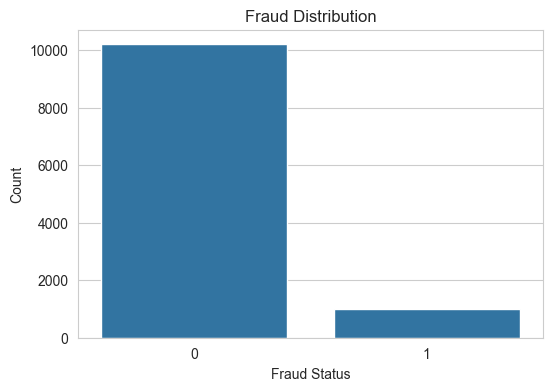

In [31]:
# Fraud Distribution Visualization
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=df)

plt.title("Fraud Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

## 2. Fraud vs Transaction Amount

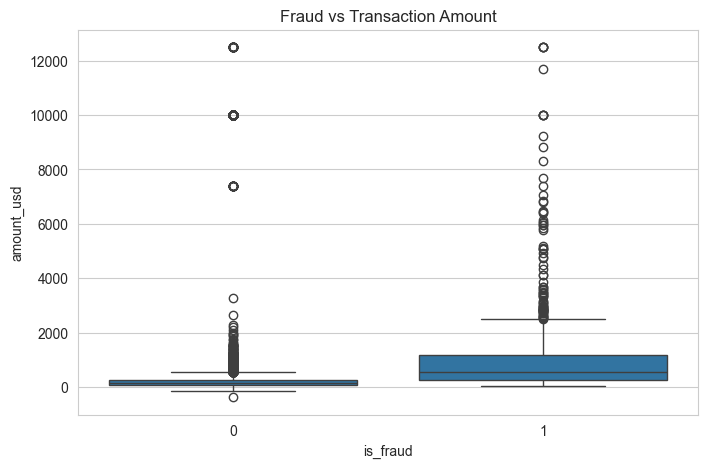

In [32]:
# Fraud vs Transaction Amount

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="amount_usd",
    data=df
)

plt.title("Fraud vs Transaction Amount")

plt.show()

## 3. Fraud vs Fee

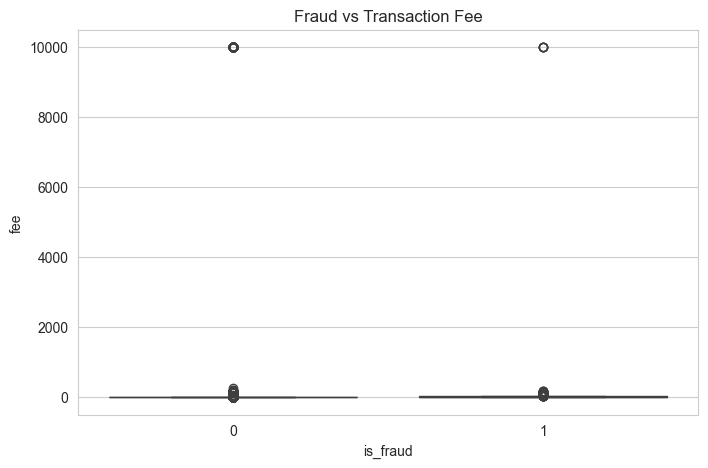

In [33]:
# Fraud vs Transaction Fee

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="fee",
    data=df
)

plt.title("Fraud vs Transaction Fee")

plt.show()

## 4. Fraud vs Exchange Rate

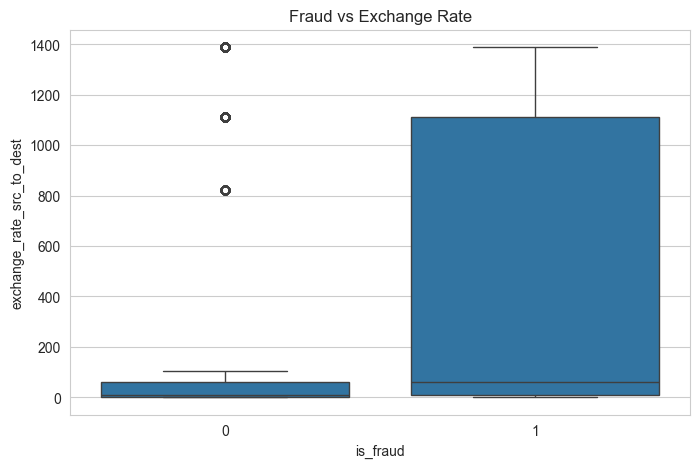

In [34]:
# Fraud vs Exchange Rate

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="exchange_rate_src_to_dest",
    data=df
)

plt.title("Fraud vs Exchange Rate")

plt.show()

## 5. Fraud vs IP Risk Score

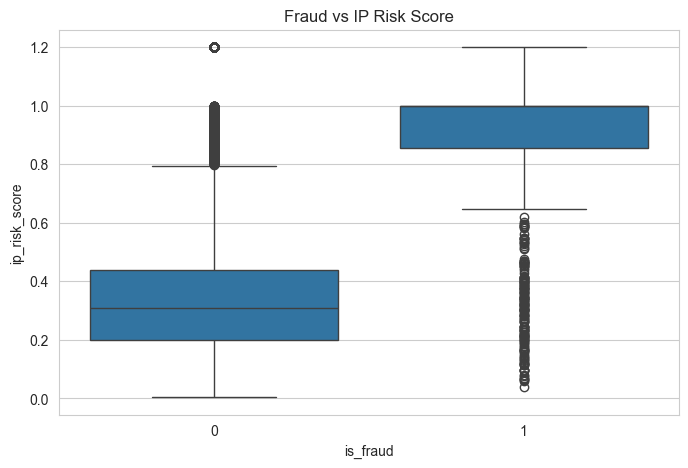

In [35]:
# Fraud vs IP Risk Score

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="ip_risk_score",
    data=df
)

plt.title("Fraud vs IP Risk Score")

plt.show()

## 6. Fraud vs Device Trust Score

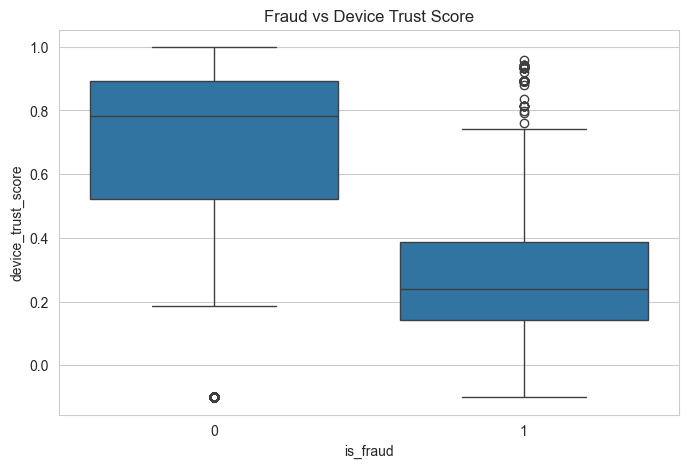

In [36]:
# Fraud vs Device Trust Score

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="device_trust_score",
    data=df
)

plt.title("Fraud vs Device Trust Score")

plt.show()

## 7. Fraud by Transaction Channel

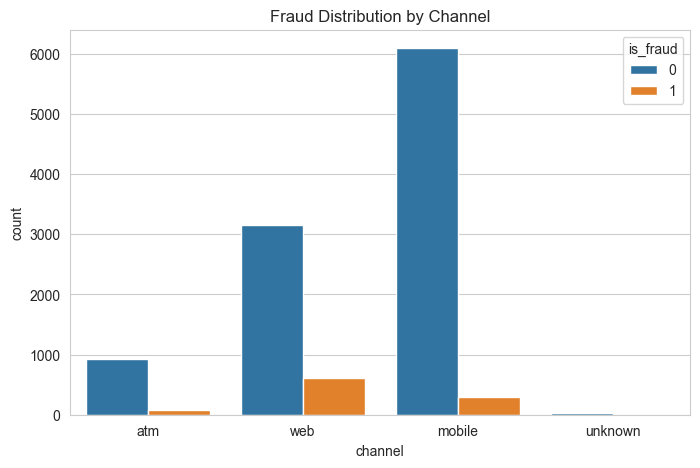

In [37]:
# Fraud vs Device Trust Score

plt.figure(figsize=(8,5))

sns.countplot(
    x="channel",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by Channel")

plt.show()

## 8. Fraud by KYC Tier

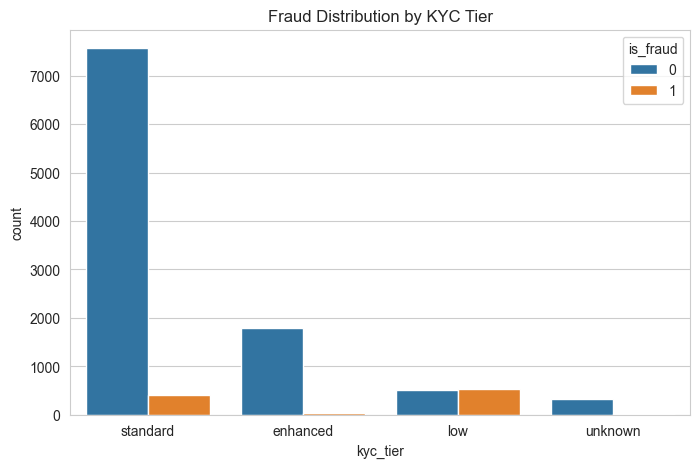

In [38]:
# Fraud by KYC Tier

plt.figure(figsize=(8,5))

sns.countplot(
    x="kyc_tier",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by KYC Tier")

plt.show()

## 9. Fraud vs Location Mismatch

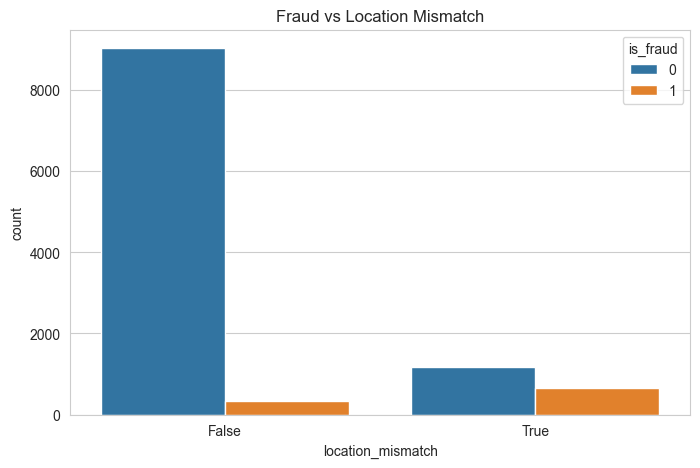

In [39]:
# Fraud by Location Mismatch

plt.figure(figsize=(8,5))

sns.countplot(
    x="location_mismatch",
    hue="is_fraud",
    data=df
)

plt.title("Fraud vs Location Mismatch")

plt.show()

## 10. Fraud vs New Device

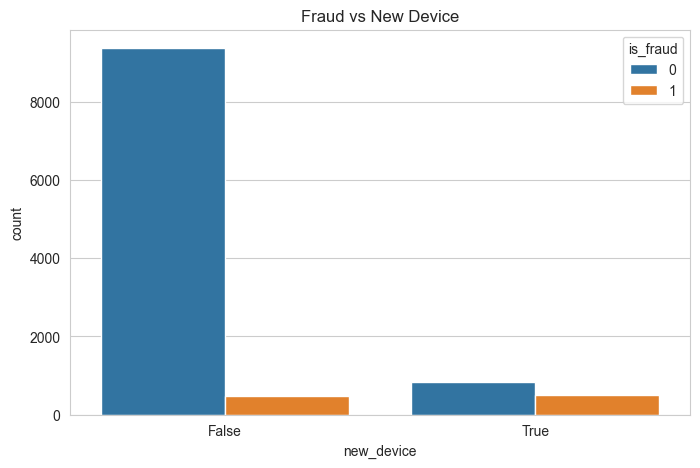

In [40]:
# Fraud by New Device

plt.figure(figsize=(8,5))

sns.countplot(
    x="new_device",
    hue="is_fraud",
    data=df
)

plt.title("Fraud vs New Device")

plt.show()

## 11. Fraud by Transaction Hour


In [41]:
# Restore timestamp from original dataset
df["timestamp"] = original_df["timestamp"]

# Convert timestamp properly
df["timestamp"] = pd.to_datetime(
    df["timestamp"].astype(str).str.strip(),
    format="mixed",
    errors="coerce",
    utc=True
)

# Remove invalid timestamps
df = df.dropna(subset=["timestamp"])

# Create transaction hour feature
df["transaction_hour"] = df["timestamp"].dt.hour

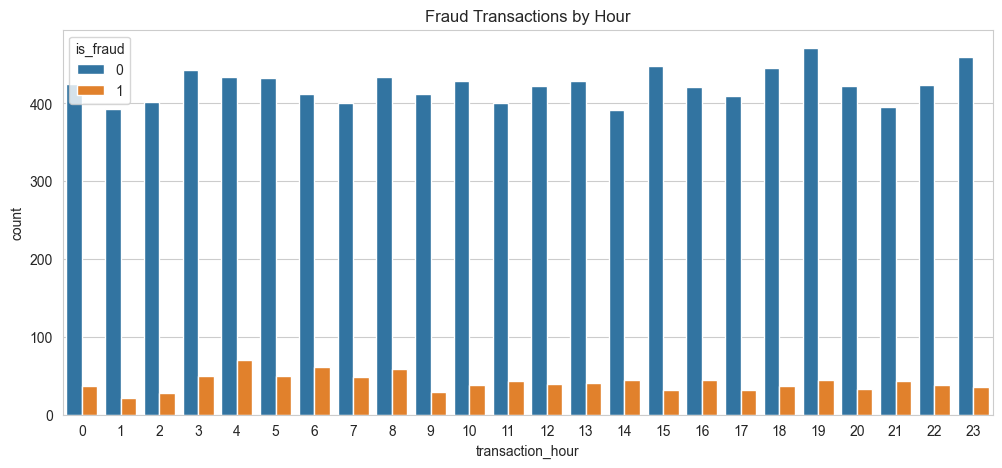

In [42]:
# Fraud by Transaction Hour
plt.figure(figsize=(12,5))

sns.countplot(
    x="transaction_hour",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Transactions by Hour")

plt.show()

## 12. Correlation with Fraud

In [43]:
# Select numerical columns
numerical_df = df.select_dtypes(
    include=["int64", "float64"]
)

# Correlation with fraud
fraud_corr = numerical_df.corr()["is_fraud"]\
                         .sort_values(ascending=False)

print(fraud_corr)

is_fraud                     1.000000
txn_velocity_24h             0.753821
txn_velocity_1h              0.691093
risk_score_internal          0.604460
chargeback_history_count     0.581409
ip_risk_score                0.523565
corridor_risk                0.195702
exchange_rate_src_to_dest    0.153344
amount_src                   0.130683
amount_usd                   0.130073
fee                         -0.013567
account_age_days            -0.286471
device_trust_score          -0.394220
Name: is_fraud, dtype: float64


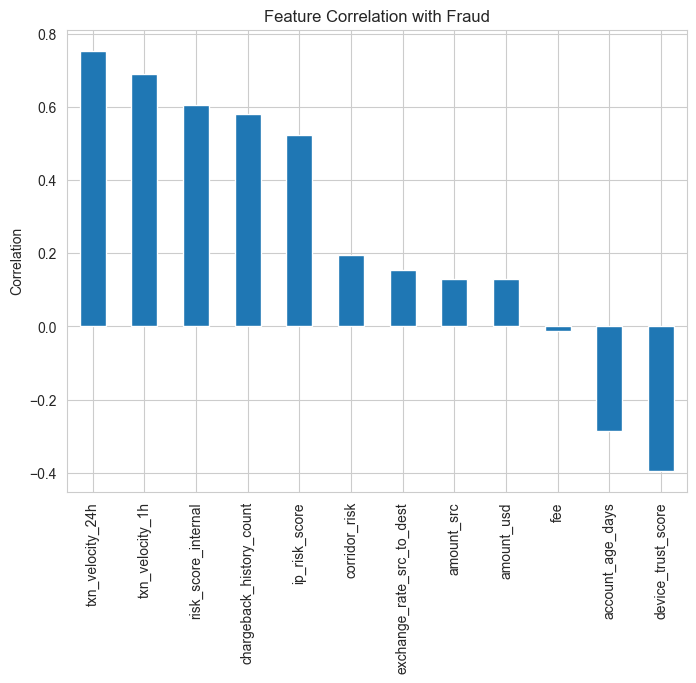

In [44]:
# Correlation with fraud - Visualization
plt.figure(figsize=(8,6))

fraud_corr.drop("is_fraud").plot(
    kind="bar"
)

plt.title("Feature Correlation with Fraud")

plt.ylabel("Correlation")

plt.show()

## 13. Fraud Rate by Country

In [45]:
fraud_country = df.groupby(
    "home_country"
)["is_fraud"].mean() * 100

print(
    fraud_country.sort_values(ascending=False)
)

home_country
ca         15.276631
uk         13.358779
us          6.744156
unknown     0.000000
Name: is_fraud, dtype: float64


## 14. Fraud vs Transaction Velocity

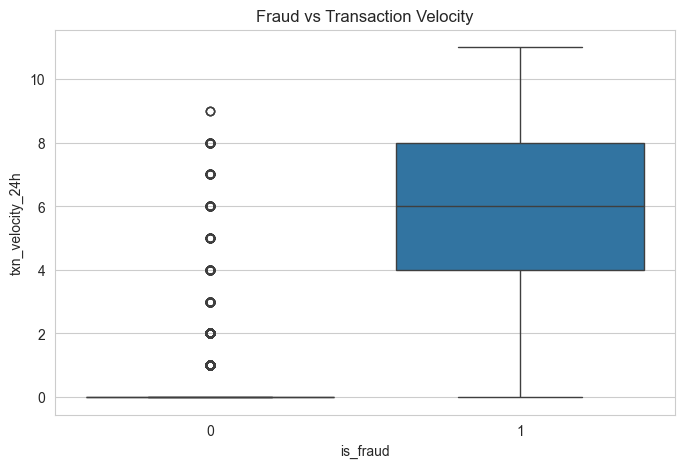

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="txn_velocity_24h",
    data=df
)

plt.title("Fraud vs Transaction Velocity")

plt.show()

## Dealing with Outliers in amount_usd, Fee, and exchange rate
Note:
- This is NOT an outlier error.

- It is a valid currency conversion.

- So removing these values would damage the dataset.
### The most suitable way is by log transformation

In [47]:

# Apply log transformation to Amount USD to reduce skewness and handle outliers

df["log_amount_usd"] = np.log1p(df["amount_usd"])

# Apply log transformation to Fee to reduce skewness and handle outliers
df["log_fee"] = np.log1p(df["fee"])

# Apply log transformation to Exchange Rate to reduce skewness and handle outliers
df["log_exchange_rate"] = np.log1p(df["exchange_rate_src_to_dest"])


c:\Datascience_Projects\Fraud_Detection_Project\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Datascience_Projects\Fraud_Detection_Project\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Visualize After Transformation

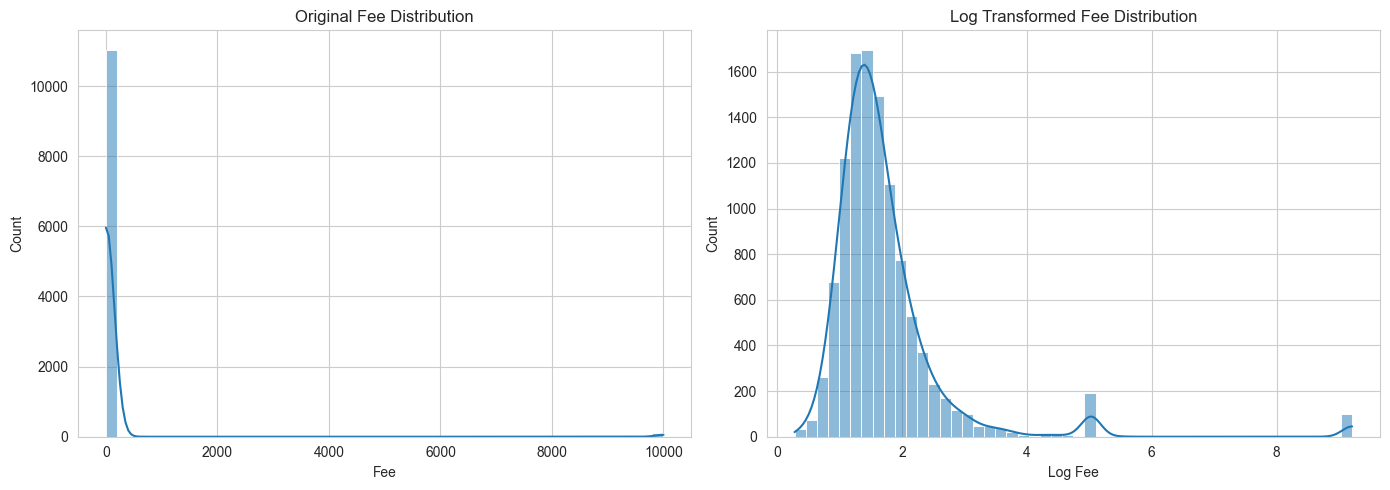

In [48]:
# =========================================
# Compare Original vs Log Fee Distribution
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original fee distribution
sns.histplot(
    df["fee"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Fee Distribution")
axes[0].set_xlabel("Fee")


# Log transformed fee distribution
sns.histplot(
    df["log_fee"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Fee Distribution")
axes[1].set_xlabel("Log Fee")

plt.tight_layout()

plt.show()

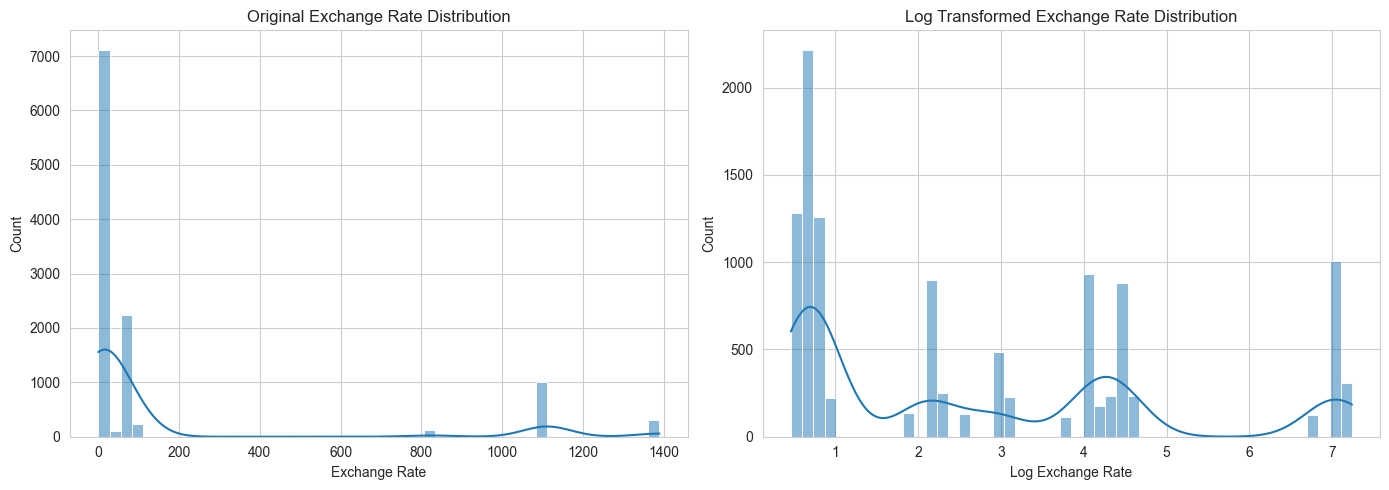

In [49]:
# =========================================
# Compare Original vs Log Exchange Rate
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original exchange rate distribution
sns.histplot(
    df["exchange_rate_src_to_dest"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Exchange Rate Distribution")
axes[0].set_xlabel("Exchange Rate")


# Log transformed exchange rate distribution
sns.histplot(
    df["log_exchange_rate"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Exchange Rate Distribution")
axes[1].set_xlabel("Log Exchange Rate")

plt.tight_layout()

plt.show()

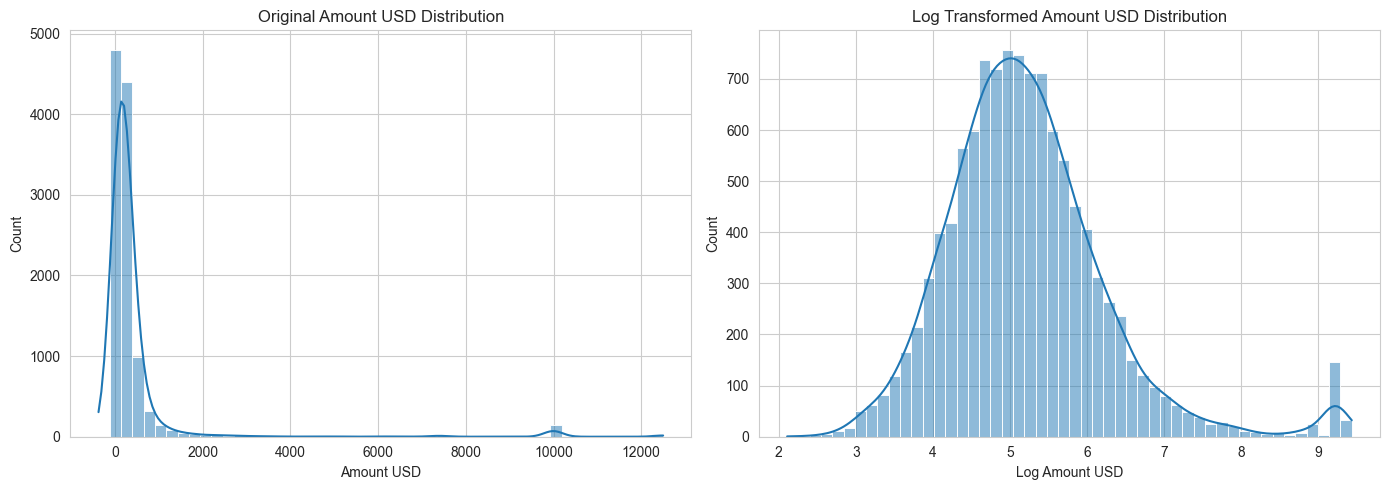

In [50]:
# =========================================
# Compare Original vs Log Amount Distribution
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original amount distribution
sns.histplot(
    df["amount_usd"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Amount USD Distribution")
axes[0].set_xlabel("Amount USD")


# Log transformed amount distribution
sns.histplot(
    df["log_amount_usd"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Amount USD Distribution")
axes[1].set_xlabel("Log Amount USD")

plt.tight_layout()

plt.show()

# 8. Save EDA-Enhanced Dataset

In [51]:
from pathlib import Path
base_dir = Path.cwd()
output_dir = base_dir / 'data' if (base_dir / 'data').exists() else base_dir.parent / 'data'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'nova_pay_eda_ready.csv'
df.to_csv(output_path, index=False)

print(f"EDA-ready dataset saved successfully to {output_path}")

EDA-ready dataset saved successfully to c:\Datascience_Projects\Fraud_Detection_Project\data\nova_pay_eda_ready.csv
